# Erasmus KA1 Mobility Analysis: Duration Analysis by Education Level and Field of Education

This notebook analyzes the **Erasmus KA1 Mobility dataset**, focusing on how the **duration of a mobility period** relates to:

- The **level of education** (ISCED classification, e.g. Bachelor's, Master's, PhD)
- The **field of education** (e.g. Engineering, Business, Arts, etc.)

The goal is to identify statistically significant patterns.

**Workflow overview:**
1. Compute descriptive statistics (mean, median, standard deviation) grouped by category
2. Run statistical tests (correlation, ANOVA, t-test) to check significance
3. Visualize the results with comparative bar charts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
import textwrap

### Load the dataset

In [2]:
df = pd.read_csv('Datasets/Processed/Erasmus-Data.csv', index_col=0, low_memory=False)
df = df.reset_index(drop=True)
print(df.shape)

(3172958, 14)


## Mobility Duration by Education Level (ISCED)

This step investigates whether the **level of education** (ISCED code) has an effect on how long a mobility period lasts.

- **Spearman correlation** tests whether there is a monotonic relationship between education level and mobility duration.
- **One-way ANOVA** tests whether the mean mobility duration differs significantly across the five ISCED groups.
- **Welch's t-test** is used since ISCED-6 (Bachelor's level) has by far the most records and the highest mean, it's compared directly against all other levels combined to confirm the difference is statistically significant.

In [ ]:
df = pd.read_csv("./Datasets/Processed/Erasmus-Data.csv", index_col=0, low_memory=False)

# label inconsistency ("Short-cycle" vs "Short cycle")
df["Education Level"] = df["Education Level"].str.replace(
    "Short-cycle within", "Short cycle within", regex=False
)
df["ISCED_code"] = df["Education Level"].str.extract(r"ISCED-(\d)").astype(int)

summary = df.groupby("ISCED_code")["Mobility Duration"].agg(["count", "mean", "median", "std"]).round(1)
print(summary)

corr, p_corr = stats.spearmanr(df["ISCED_code"], df["Mobility Duration"])
print(f"Spearman correlation (ISCED code vs duration): rho={corr:.4f}, p={p_corr:.8f}")

f_stat, p_anova = stats.f_oneway(*[g["Mobility Duration"].values for _, g in df.groupby("ISCED_code")])
print(f"One-way ANOVA across ISCED groups: F={f_stat:.4f}, p={p_anova:.2e}")

isced6 = df.loc[df["ISCED_code"] == 6, "Mobility Duration"]
rest = df.loc[df["ISCED_code"] != 6, "Mobility Duration"]
t_stat, p_t = stats.ttest_ind(isced6, rest, equal_var=False)

print(
    f"\nISCED-6 mean duration: {isced6.mean():.1f} days (n={len(isced6)})"
    f"\nAll other levels mean: {rest.mean():.1f} days (n={len(rest)})"
    f"\nWelch t-test: t={t_stat:.2f}, p={p_t:.2e}"
)

              count   mean  median   std
ISCED_code                              
5             91284   89.0    74.0  53.0
6           1986585  152.2   137.0  73.0
7           1012284  144.4   136.0  69.1
8             55348  100.4    90.0  73.3
9             27457  142.4   129.0  67.8
Spearman correlation (ISCED code vs duration): rho=0.0057, p=0.00000000
One-way ANOVA across ISCED groups: F=24068.8748, p=0.00e+00

ISCED-6 mean duration: 152.2 days (n=1986585)
All other levels mean: 138.0 days (n=1186373)
Welch t-test: t=171.27, p=0.00e+00


The correlation is extreamly weak: `Education Level` alone does not predict `Mobility Duration`.

With the Spearman correlation, we found rho close to 0. That indicates a very weak relationship.

## Mobility Duration by Field of Education

- Compute the **overall statistics** across the whole dataset (`duration_stats`), used later as a benchmark line in the charts.
- Run a **one-way ANOVA** to test whether mean mobility duration differs significantly across fields of education.
- Compute **eta-squared (η²)**, an effect size measure that quantifies *how much* of the variance in mobility duration is explained by the field of study.

In [10]:
df = pd.read_csv("./Datasets/Processed/Erasmus-Data.csv", index_col=0, low_memory=False)

summary = df.groupby("Field of Education")["Mobility Duration"].agg(["count", "mean", "median", "std"]).round(1)
summary_sorted_mean = summary.sort_values("mean", ascending=False)
summary_sorted_median = summary.sort_values("median", ascending=False)
duration_stats = df["Mobility Duration"].agg(["count", "mean", "median", "std"]).round(1).to_frame().T.reset_index(drop=True)

f_stat, p_anova = stats.f_oneway(*[g["Mobility Duration"].values for _, g in df.groupby("Field of Education")])
print(f"One-way ANOVA across Field of Education groups: F={f_stat:.4f}, p={p_anova:.2e}")

grand_mean = df["Mobility Duration"].mean()
ss_between = sum(len(g) * (g["Mobility Duration"].mean() - grand_mean) ** 2 for _, g in df.groupby("Field of Education"))
ss_total = ((df["Mobility Duration"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total
print(f"Effect size (eta-squared): {eta_sq:.4f}")

One-way ANOVA across Field of Education groups: F=1290.8697, p=0.00e+00
Effect size (eta-squared): 0.0417


### Plots by Mean and Median Mobility Duration

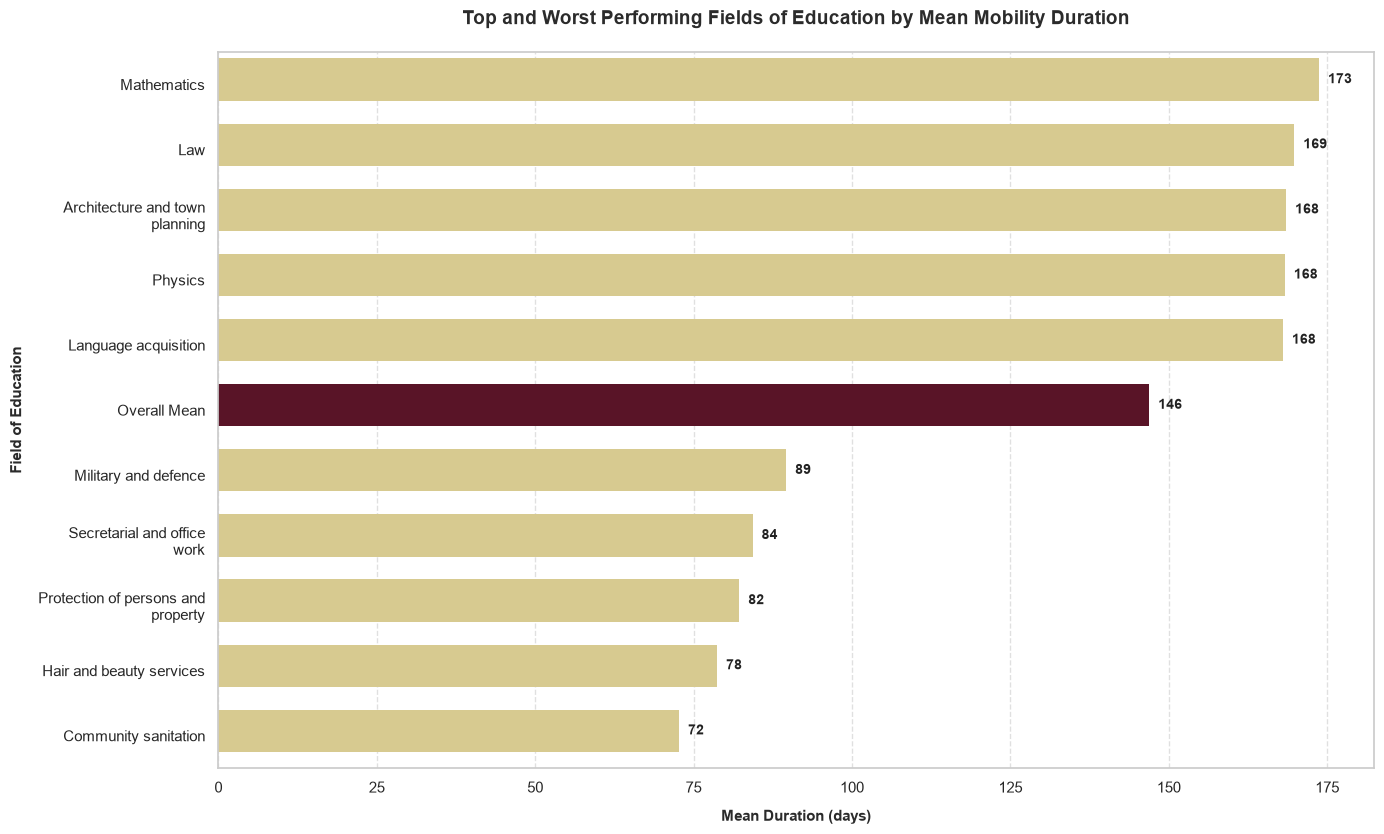

In [11]:
summary_sorted_top = summary_sorted_mean.head(5).copy()
summary_sorted_bottom = summary_sorted_mean.tail(6).copy()
summary_sorted_bottom = summary_sorted_bottom.drop(summary_sorted_bottom.index[-1])

summary_sorted_top['Wrapped Field'] = summary_sorted_top.index
summary_sorted_bottom['Wrapped Field'] = summary_sorted_bottom.index
duration_stats['Wrapped Field'] = 'Overall Mean'

summary_combined = pd.concat([summary_sorted_top, duration_stats, summary_sorted_bottom])

summary_combined['Wrapped Field'] = summary_combined['Wrapped Field'].apply(
    lambda x: textwrap.fill(str(x), width=25)
)

# Plot
plt.figure(figsize=(14, 8.5))
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    data=summary_combined,
    y='Wrapped Field',
    x='mean',
    color='#E3D184',
    edgecolor='none',
    height=0.65
)


for i, label in enumerate(summary_combined['Wrapped Field']):

    if label == 'Overall Mean':
        ax.patches[i].set_facecolor('#591427')

for i, p in enumerate(ax.patches):
    width = p.get_width()
    if width > 0:
        label = summary_combined['Wrapped Field'].iloc[i]
        ax.text(
                    width + 0.8, 
                    p.get_y() + p.get_height() / 2, 
                    f' {int(width):,}',
                    va='center', 
                    ha='left', 
                    fontsize=10, 
                    fontweight='bold', 
                    color='#222222'
                )

# Typography and aesthetics adjustments
ax.set_title('Top and Worst Performing Fields of Education by Mean Mobility Duration', 
             fontsize=14, pad=20, weight='bold', color='#2b2b2b')
ax.set_xlabel('Mean Duration (days)', fontsize=11, labelpad=10, weight='semibold', color='#2b2b2b')
ax.set_ylabel('Field of Education', fontsize=11, labelpad=10, weight='semibold', color='#2b2b2b')


ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig("Plots/Top vs Worst Performing Fields of Education by Mean Mobility Duration.png", dpi=800, bbox_inches="tight")
plt.show()

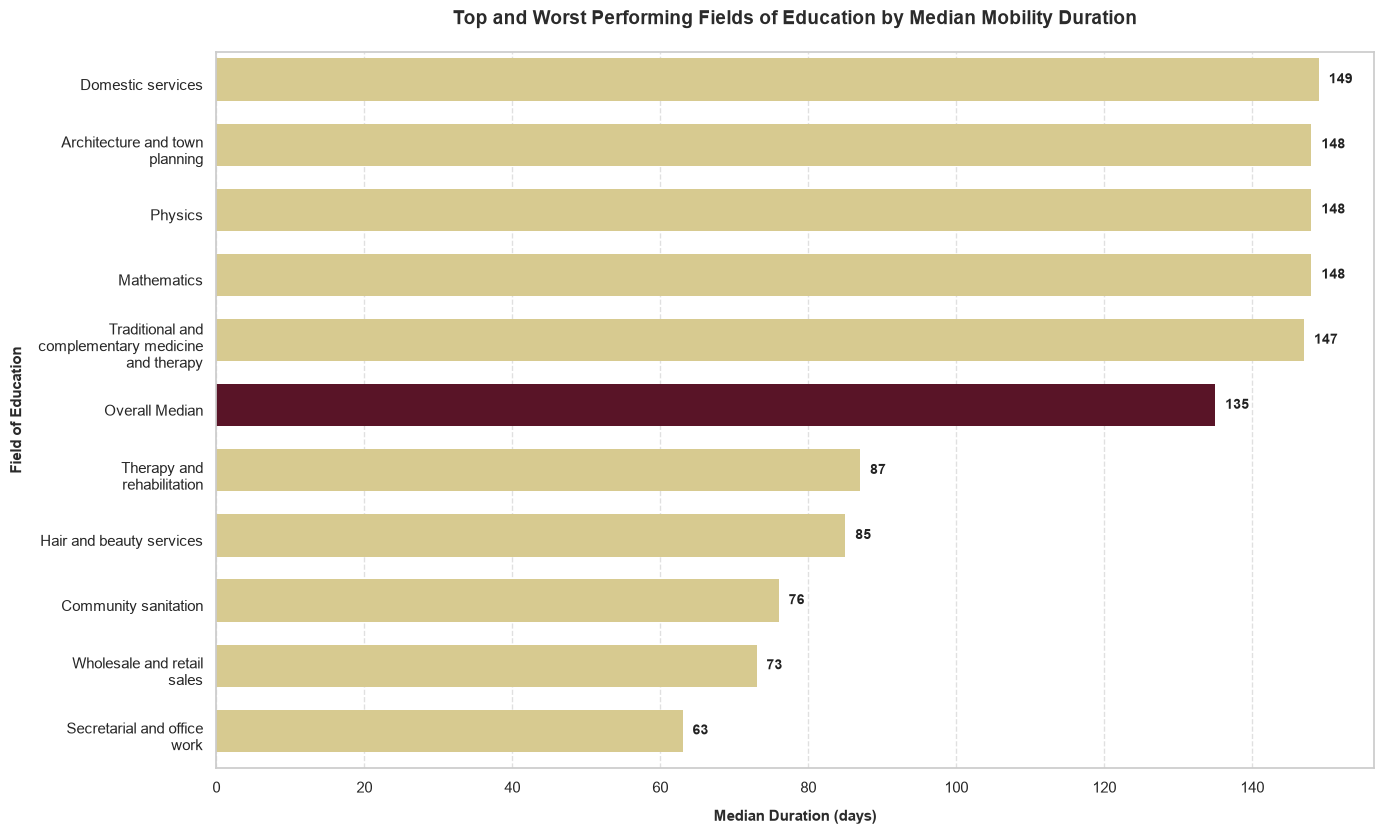

In [12]:
summary_sorted_median = summary.sort_values("median", ascending=False)
summary_sorted_top = summary_sorted_median.head(5).copy()
summary_sorted_bottom = summary_sorted_median.tail(6).copy()
summary_sorted_bottom = summary_sorted_bottom.drop(summary_sorted_bottom.index[-1])

summary_sorted_top['Wrapped Field'] = summary_sorted_top.index
summary_sorted_bottom['Wrapped Field'] = summary_sorted_bottom.index
duration_stats['Wrapped Field'] = 'Overall Median'

summary_combined = pd.concat([summary_sorted_top, duration_stats, summary_sorted_bottom])

summary_combined['Wrapped Field'] = summary_combined['Wrapped Field'].apply(
    lambda x: textwrap.fill(str(x), width=25)
)

# Plot
plt.figure(figsize=(14, 8.5))
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    data=summary_combined,
    y='Wrapped Field',
    x='median',
    color='#E3D184',
    edgecolor='none',
    height=0.65
)

for i, label in enumerate(summary_combined['Wrapped Field']):

    if label == 'Overall Median':
        ax.patches[i].set_facecolor('#591427')

for i, p in enumerate(ax.patches):
    width = p.get_width()
    if width > 0:
        label = summary_combined['Wrapped Field'].iloc[i]
        ax.text(
                    width + 0.8, 
                    p.get_y() + p.get_height() / 2, 
                    f' {int(width):,}',
                    va='center', 
                    ha='left', 
                    fontsize=10, 
                    fontweight='bold', 
                    color='#222222'
                )
        

# Typography and aesthetics adjustments
ax.set_title('Top and Worst Performing Fields of Education by Median Mobility Duration', 
             fontsize=14, pad=20, weight='bold', color='#2b2b2b')
ax.set_xlabel('Median Duration (days)', fontsize=11, labelpad=10, weight='semibold', color='#2b2b2b')
ax.set_ylabel('Field of Education', fontsize=11, labelpad=10, weight='semibold', color='#2b2b2b')


ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig("Plots/Top vs Worst Performing Fields of Education by Median Mobility Duration.png", dpi=800, bbox_inches="tight")
plt.show()